# **Probability and Distibution Practice**

In [60]:
# Rolling dice probability function
def roll(n:int,k:int):
    '''
    n: total number of possibilities
    k: number of successful possiblities
    '''
    return k/n

# Stacked independent probabilities
def indep(prob:list):
    '''
    prob: list of separate probabilities
    '''
    import math
    return math.prod(prob)
 

In [61]:
# Random variable example
prob_x = roll(6,1)
x = indep([prob_x]*3)
print(f'x is {1/x}')

x is 216.0


### Variance
* The change the expectation in variable x with small change of variable amount
* The squared difference between the current value and the expected value

### Standard deviation
* The square root of variance

### Covariance
* An indicator of whether two samples move in the same or opposite directions

### Correlation
* A magnitude of the relationship between the movement of two samples under the influence of the same factors

### Stock portfolio example
Assume the covariance of the returns from the two companies is zero &ndash; What are the expected return and standard deviation of your portfolio if you invested 50% into ABC and 50% into XYZ?

In [62]:
# Expected values
E_return_ABC = 1.2
E_return_XYZ = 1.1

# Standard deviations
sigma_ABC = 0.26
sigma_XYZ = 0.16

# Total exected value
E_return_port = 0.5*E_return_ABC + 0.5*E_return_XYZ
print(f'Expected portfolio return: {E_return_port*100:.0f}%')



Expected portfolio return: 115%


### Let's get into the code

In [63]:
# Dependencies and libraries
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(rc={'figure.figsize':(10,7)})

In [64]:
# Setting a seed so the example is reproducible
np.random.seed(4272018)

df = pd.DataFrame(np.random.randint(low=0,high=20,size=(5,2)),
                  columns = ['Commercials Watched','Product Purchases'])
display(df)

,Commercials Watched,Product Purchases
0,10,13
1,15,0
2,7,7
3,2,4
4,16,11


In [65]:
variance_com = df['Commercials Watched'].var()
print(f'Variance of commercials watched: {variance_com}')
variance_prod = df['Product Purchases'].var()
print(f'Variance of product purchases: {variance_prod}')
covariance = df[['Commercials Watched','Product Purchases']].cov()
print(f'Covariance of commercials watched and products purchased: {covariance['Commercials Watched']['Product Purchases']}')


Variance of commercials watched: 33.5
Variance of product purchases: 27.5
Covariance of commercials watched and products purchased: 3.25


In [66]:
# Correlation
study = ['Commercials Watched', 'Product Purchases']
correlation = df[study].corr()
print('Correlation between commercials watched and product purchases:')
display(correlation)

Correlation between commercials watched and product purchases:


,Commercials Watched,Product Purchases
Commercials Watched,1.000000,0.107077
Product Purchases,0.107077,1.000000


Need work understanding Bernoulli & Binomial distribution

### Experimenting with binomial distribution

In [67]:
from scipy.stats import binom

samples = binom.rvs(n=1,p=0.5,size=5000)
print(type(samples))
print(samples.mean())
print(samples[:10])

<class 'numpy.ndarray'>
0.5078
[1 1 1 1 1 1 0 1 0 1]


In [68]:
# Soccer players 1 through 22
athletes = [f'Player{i}' for i in range(1,23)]

# Game minutes from 1 to 120 (double overtime)
minutes = np.arange(0,125,5)

# Game dataframe - injures per player at each time interval
injury_df = pd.DataFrame(columns=athletes,index=minutes)
display(injury_df.head())

,Player1,Player2,Player3,Player4,Player5,Player6,Player7,Player8,Player9,Player10,...,Player13,Player14,Player15,Player16,Player17,Player18,Player19,Player20,Player21,Player22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Function options to skew binomial distribution of injuries

In [69]:
# Option 1 - sum of Gaussian curves
a, b, c, d, e = [1]*5

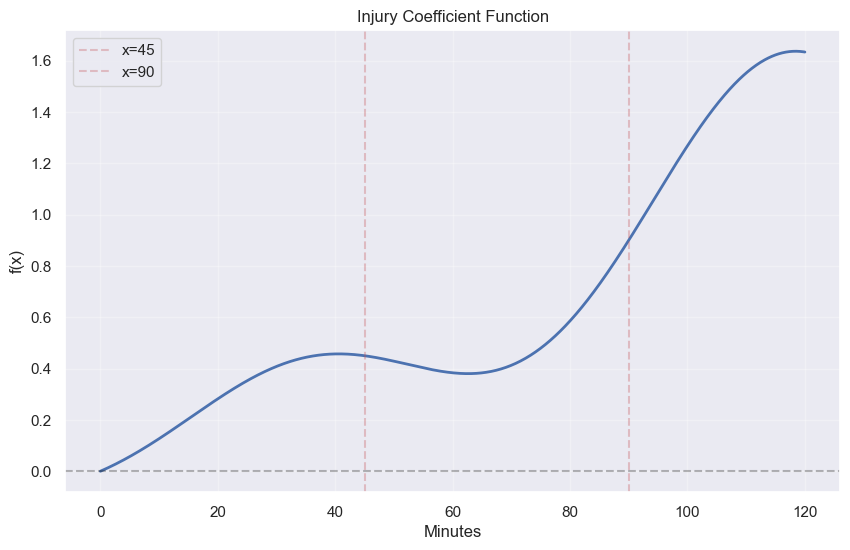

f(0) = 0.0000
f(45) = 0.4500
f(90) = 0.9000
f(120) = 1.6330


In [ ]:
# Option 2 - polynomial function
def f(x):
    a = -1e-6
    return a * x * (x - 45)**2 * (x - 90)**2

# Generate x values from 0 to 120
x = np.linspace(0, 120, 1000)
y = f(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=45, color='r', linestyle='--', alpha=0.3, label='x=45')
plt.axvline(x=90, color='r', linestyle='--', alpha=0.3, label='x=90')
plt.xlabel('Minutes')
plt.ylabel('f(x)')
plt.title('Injury Coefficient Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Print key values
print(f"f(0) = {f(0):.4f}")
print(f"f(45) = {f(45):.4f}")
print(f"f(90) = {f(90):.4f}")
print(f"f(120) = {f(120):.4f}")